# **1st Experiment**

Notebook ini berisi eksperimen terkait modeling untuk menjawab rasa penasaran tentang apa yang terjadi jika dilakukan Imputasi terhadap missing value, Apakah ada teknik sampling tertentu yang meningkatkan hasil prediksi, apakah feature selection berpengaruh dan juga hyper parameter tuning. Untuk bagian sampling dan hyperparameter tuning akan di buat lebih terstruktur dan terfokus di notebook eksperimen modeling bagian ke dua.

# Dependencies

In [ ]:
%pip install -qq pandas 
%pip install -qq numpy 
%pip install -qq scikit-learn 
%pip install -qq xgboost 
%pip install -qq imblearn 
%pip install -qq tabulate
%pip install -qq xgbimputer
%pip install -qq lightgbm
%pip install -qq catboost

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
^C
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, cross_val_predict, KFold, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder, FunctionTransformer, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, OneSidedSelection
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from scipy.stats import randint, uniform
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance
from xgbimputer import XGBImputer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from tabulate import tabulate
import matplotlib.pyplot as plt
import lightgbm as lgb
import catboost as cb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna


pd.set_option('display.max_columns', 200)


# Load

In [ ]:
app_df = pd.read_csv("https://raw.githubusercontent.com/arawsardni/5---Gaung-Taqwa-Indraswara---Sandra-Triana-Nursyafri/refs/heads/main/Dataset/raw/application_record.csv")
cred_df = pd.read_csv("https://raw.githubusercontent.com/arawsardni/5---Gaung-Taqwa-Indraswara---Sandra-Triana-Nursyafri/refs/heads/main/Dataset/raw/credit_record.csv")

In [ ]:
app_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [ ]:
cred_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
cred_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


# Creating Target

In [ ]:
is_bad = (
    cred_df['STATUS']
    .isin(['3','4','5'])
    .groupby(cred_df['ID'])
    .max()  # Jika ada minimal 1 True, return 1
    .astype(int)
)

# Aggregrating Credit Records

In [ ]:
credit_agg = cred_df.groupby('ID').agg(
    CREDIT_HISTORY_LENGTH=('MONTHS_BALANCE', lambda x: abs(x.min() - x.max()) + 1)).reset_index()
    
# Gabungkan target dengan fitur agregasi kredit
credit_agg['IS_BAD'] = is_bad.values

In [ ]:
cred_df['MONTHS_BALANCE'].describe()


count    1.048575e+06
mean    -1.913700e+01
std      1.402350e+01
min     -6.000000e+01
25%     -2.900000e+01
50%     -1.700000e+01
75%     -7.000000e+00
max      0.000000e+00
Name: MONTHS_BALANCE, dtype: float64

In [ ]:
credit_agg

,ID,CREDIT_HISTORY_LENGTH,IS_BAD
0,5001711,4,0
1,5001712,19,0
2,5001713,22,0
3,5001714,15,0
4,5001715,60,0
...,...,...,...
45980,5150482,18,0
45981,5150483,18,0
45982,5150484,13,0
45983,5150485,2,0


# Merge Data

In [ ]:
new_df = pd.merge(app_df, credit_agg, on="ID", how="inner")

In [ ]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,16,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,15,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,30,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,12,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,24,1
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,33,1
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,10,0


In [ ]:
new_df.isna().sum()

ID                           0
CODE_GENDER                  0
FLAG_OWN_CAR                 0
FLAG_OWN_REALTY              0
CNT_CHILDREN                 0
AMT_INCOME_TOTAL             0
NAME_INCOME_TYPE             0
NAME_EDUCATION_TYPE          0
NAME_FAMILY_STATUS           0
NAME_HOUSING_TYPE            0
DAYS_BIRTH                   0
DAYS_EMPLOYED                0
FLAG_MOBIL                   0
FLAG_WORK_PHONE              0
FLAG_PHONE                   0
FLAG_EMAIL                   0
OCCUPATION_TYPE          11323
CNT_FAM_MEMBERS              0
CREDIT_HISTORY_LENGTH        0
IS_BAD                       0
dtype: int64

In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     36457 non-null  int64  
 1   CODE_GENDER            36457 non-null  object 
 2   FLAG_OWN_CAR           36457 non-null  object 
 3   FLAG_OWN_REALTY        36457 non-null  object 
 4   CNT_CHILDREN           36457 non-null  int64  
 5   AMT_INCOME_TOTAL       36457 non-null  float64
 6   NAME_INCOME_TYPE       36457 non-null  object 
 7   NAME_EDUCATION_TYPE    36457 non-null  object 
 8   NAME_FAMILY_STATUS     36457 non-null  object 
 9   NAME_HOUSING_TYPE      36457 non-null  object 
 10  DAYS_BIRTH             36457 non-null  int64  
 11  DAYS_EMPLOYED          36457 non-null  int64  
 12  FLAG_MOBIL             36457 non-null  int64  
 13  FLAG_WORK_PHONE        36457 non-null  int64  
 14  FLAG_PHONE             36457 non-null  int64  
 15  FL

In [ ]:
new_df["IS_BAD"].value_counts(normalize=True)

IS_BAD
0    0.991716
1    0.008284
Name: proportion, dtype: float64

In [ ]:
new_df["IS_BAD"].value_counts()

IS_BAD
0    36155
1      302
Name: count, dtype: int64

In [ ]:
for column in new_df.select_dtypes(include='object'):
    unique_values = new_df[column].unique()
    print(f"Unique values in {column}: {unique_values}")

Unique values in CODE_GENDER: ['M' 'F']
Unique values in FLAG_OWN_CAR: ['Y' 'N']
Unique values in FLAG_OWN_REALTY: ['Y' 'N']
Unique values in NAME_INCOME_TYPE: ['Working' 'Commercial associate' 'Pensioner' 'State servant' 'Student']
Unique values in NAME_EDUCATION_TYPE: ['Higher education' 'Secondary / secondary special' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
Unique values in NAME_FAMILY_STATUS: ['Civil marriage' 'Married' 'Single / not married' 'Separated' 'Widow']
Unique values in NAME_HOUSING_TYPE: ['Rented apartment' 'House / apartment' 'Municipal apartment'
 'With parents' 'Co-op apartment' 'Office apartment']
Unique values in OCCUPATION_TYPE: [nan 'Security staff' 'Sales staff' 'Accountants' 'Laborers' 'Managers'
 'Drivers' 'Core staff' 'High skill tech staff' 'Cleaning staff'
 'Private service staff' 'Cooking staff' 'Low-skill Laborers'
 'Medicine staff' 'Secretaries' 'Waiters/barmen staff' 'HR staff'
 'Realty agents' 'IT staff']


# Renaming Feature

In [ ]:
new_df = new_df.rename(columns={
    "DAYS_BIRTH" : "AGE",
    "NAME_FAMILY_STATUS" : "MARITAL_STATUS",
    "NAME_HOUSING_TYPE" :  "DWELLING_TYPE",
    "AMT_INCOME_TOTAL" : "ANNUAL_INCOME",
    "OCCUPATION_TYPE" : "JOB_TITLE",
    "NAME_EDUCATION_TYPE" : "EDUCATION_LEVEL",
    "DAYS_EMPLOYED" : "EMPLOYMENT_LENGTH",
    "NAME_INCOME_TYPE" : "EMPLOYMENT_STATUS"})

In [ ]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,16,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,15,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,30,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,12,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,24,1
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,33,1
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,10,0


In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     36457 non-null  int64  
 1   CODE_GENDER            36457 non-null  object 
 2   FLAG_OWN_CAR           36457 non-null  object 
 3   FLAG_OWN_REALTY        36457 non-null  object 
 4   CNT_CHILDREN           36457 non-null  int64  
 5   ANNUAL_INCOME          36457 non-null  float64
 6   EMPLOYMENT_STATUS      36457 non-null  object 
 7   EDUCATION_LEVEL        36457 non-null  object 
 8   MARITAL_STATUS         36457 non-null  object 
 9   DWELLING_TYPE          36457 non-null  object 
 10  AGE                    36457 non-null  int64  
 11  EMPLOYMENT_LENGTH      36457 non-null  int64  
 12  FLAG_MOBIL             36457 non-null  int64  
 13  FLAG_WORK_PHONE        36457 non-null  int64  
 14  FLAG_PHONE             36457 non-null  int64  
 15  FL

In [ ]:
df_retire = new_df[new_df['EMPLOYMENT_STATUS'] == 'Pensioner']
df_retire

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0,17,0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0,17,0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0,17,0
69,5008884,F,N,Y,0,315000.0,Pensioner,Secondary / secondary special,Widow,House / apartment,-20186,365243,1,0,0,0,NaN,1.0,41,0
150,5008974,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22319,365243,1,0,0,0,NaN,2.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36432,5145690,F,N,Y,0,306000.0,Pensioner,Higher education,Married,House / apartment,-21590,365243,1,0,0,0,NaN,2.0,18,1
36434,5145817,F,N,Y,0,90000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22011,365243,1,0,0,0,NaN,2.0,40,1
36439,5148602,M,N,Y,0,225000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22946,365243,1,0,0,0,NaN,2.0,16,1
36441,5148694,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,Municipal apartment,-20600,-198,1,0,0,0,Laborers,2.0,21,0


In [ ]:
# split the data into train and test
def data_split(df, test_size):
    train_df, test_df = train_test_split(df, test_size=test_size, random_state=42)
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

In [ ]:
train_original, test_original = data_split(new_df, 0.2)

In [ ]:
train_original["IS_BAD"].value_counts(normalize=True)

IS_BAD
0    0.991291
1    0.008709
Name: proportion, dtype: float64

In [ ]:
test_original["IS_BAD"].value_counts(normalize=True)

IS_BAD
0    0.993417
1    0.006583
Name: proportion, dtype: float64

# List of Feature Preprocessing

ID:
* Drop the feature

CODE_GENDER: 
* One hot encoding

AGE from DAYS_BIRTH: 
* Min-max scaling
* Fix skewness
* Abs value and div 365.25

MARITAL_STATUS from NAME_FAMILY_STATUS: 
* One hot encoding

CNT_FAM_MEMBERS:
* Fix outliers

CNT_CHILDERN:
* Fix outliers
* Drop feature

DWELLING_TYPE from NAME_HOUSING_TYPE 
* One hot encoding

ANNUAL_INCOME from AMT_INCOME_TOTAL:
* Remove outliers
* Fix skewness
* Min-max scaling

JOB_TITLE from OCCUPATION_TYPE 
* One hot encoding


EMPLOYMENT_STATUS from NAME_INCOME_TYPE: 
* One hot encoding

EDUCATION_LEVEL from NAME_EDUCATION TYPE: 
* Ordinal encoding

EMPLOYMENT_LENGTH from DAYS_EMPLOYED: 
* Remove outliers
* Min-max scaling
* Abs value and div 365.25
* change days of employments of retirees to 0

FLAG_OWN_CAR: 
* Change it numerical
* One-hot encoding

FLAG_OWN_REALTY: 
* Change it numerical
* One-hot encoding

FLAG_MOBILE: 
* Drop feature (because all of it is 1) 

FLAG_WORK_PHONE : 
* One-hot encoding

FLAG_PHONE: 
* One-hot encoding

FLAG_EMAIL: 
* One-hot encoding

IS_BAD: 
* balance the data with SMOTE

# Preprocessing Data

In [ ]:
# Remove Outliers

def remove_outliers(df, features=['CNT_FAM_MEMBERS', 'ANNUAL_INCOME', 'EMPLOYMENT_LENGTH']):
    if set(features).issubset(df.columns):
        Q1, Q3 = df[features].quantile(0.25), df[features].quantile(0.75)
        IQR = Q3 - Q1
        df = df[~((df[features] < (Q1 - 3 * IQR)) | (df[features] > (Q3 + 3 * IQR))).any(axis=1)]
    return df

In [ ]:
# Dropping

def drop_unwanted_features(df, features=['ID', 'FLAG_MOBIL', 'CNT_CHILDREN', 'FLAG_EMAIL', 'CREDIT_HISTORY_LENGTH']):
    return df.drop(columns=[f for f in features if f in df.columns], errors='ignore')

In [ ]:
# Convert Time from -(Days) to Age

def convert_time_features(df, features=['EMPLOYMENT_LENGTH', 'AGE']):
    df[features] = df[features].abs() // 365.25
    return df

In [ ]:
# Handling Pensioner dengan Employment Status 365243 (masa bekerja tidak valid)

def handle_retirees(df):
    df.loc[df['EMPLOYMENT_LENGTH'] == 365243, 'EMPLOYMENT_LENGTH'] = 0
    return df

In [ ]:
# Memperbaiki data skewed dengan merubah value nya dengan cuberoot nya sendiri agar menghasilkan distribusi normal

def adjust_skewness(df, features=['ANNUAL_INCOME', 'AGE', "CREDIT_HISTORY_LENGTH"]):
    df[features] = np.cbrt(df[features])
    return df

In [ ]:
# Merubah Y dan N menjadi 1 dan 0

def binarize_features(df, features=['FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']):
    for feature in features:
        if feature in df.columns:
            df[feature] = df[feature].map({1: 'Y', 0: 'N'})
    return df

In [ ]:
# Melakukan One Hot Encoding ke kolom kategorikal tanpa tingkatan

def apply_one_hot_encoding(df, features=['CODE_GENDER', 'MARITAL_STATUS', 'JOB_TITLE', 'DWELLING_TYPE', 'EMPLOYMENT_STATUS', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']):
    encoder = OneHotEncoder()
    encoded_df = pd.DataFrame(encoder.fit_transform(df[features]).toarray(), columns=encoder.get_feature_names_out(features), index=df.index)
    return df.drop(columns=features).join(encoded_df)

In [ ]:
# Melakukan ordinal encoding ke kolom kategorikal dengan tingkatan (education level)

def apply_ordinal_encoding(df, features=['EDUCATION_LEVEL']):
    mapping = {'Lower secondary': 0, 
               'Secondary / secondary special': 1, 
               'Incomplete higher': 2,  
               'Higher education': 3, 
               'Academic degree': 4}
    
    for feature in features:
        df[feature] = df[feature].map(mapping)
    
    return df


In [ ]:
# scaling numerical featurse dengan min max, karena sudah dibersihkan outliersnya

def scale_features(df, features=['AGE', 'ANNUAL_INCOME', 'EMPLOYMENT_LENGTH', 'CREDIT_HISTORY_LENGTH']):
    df[features] = StandardScaler().fit_transform(df[features])
    return df

In [ ]:
def apply_oversampling(df):
    smote = SMOTE(sampling_strategy='minority', random_state=42)
    X_bal, y_bal = smote.fit_resample(df.drop(columns=['IS_BAD']), df['IS_BAD'])
    return pd.concat([pd.DataFrame(X_bal), pd.DataFrame(y_bal, columns=['IS_BAD'])], axis=1)


In [ ]:
def apply_xgb_imputation(df):
    df_copy = df.copy()
    
    # Pisahkan data dengan dan tanpa missing values
    df_train = df_copy[df_copy['JOB_TITLE'].notna()]
    df_missing = df_copy[df_copy['JOB_TITLE'].isna()]
    
    if df_missing.empty:
        return df_copy  # Tidak ada missing value, langsung return
    
    # Encode target variable (JOB_TITLE) menjadi numerik
    JOB_TITLE_mapping = {val: idx for idx, val in enumerate(df_train['JOB_TITLE'].unique())}
    df_train['JOB_TITLE'] = df_train['JOB_TITLE'].map(JOB_TITLE_mapping)
    
    # Fitur dan target
    X_train = df_train.drop(columns=['JOB_TITLE'])
    y_train = df_train['JOB_TITLE']
    X_missing = df_missing.drop(columns=['JOB_TITLE'])
    
    # Model XGBoost
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
    model.fit(X_train, y_train)
    
    # Prediksi nilai yang hilang
    y_pred = model.predict(X_missing)
    
    # Mapping kembali ke kategori aslinya
    reverse_mapping = {v: k for k, v in JOB_TITLE_mapping.items()}
    df_copy.loc[df_copy['JOB_TITLE'].isna(), 'JOB_TITLE'] = [reverse_mapping[val] for val in y_pred]
    
    return df_copy

In [ ]:
# full preprocessed yang akan nanti kta pakai di akhir

def full_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    df = apply_xgb_imputation(df)
    df = adjust_skewness(df)
    df = binarize_features(df)
    df = apply_one_hot_encoding(df)
    df = apply_ordinal_encoding(df)
    df = scale_features(df)
    df = apply_oversampling(df)
    return df


# List of Classifier

In [ ]:
classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),  # ✅ Paralelisasi
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),  # ✅ Paralelisasi
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1),  # ✅ Paralelisasi
    "LightGBM": lgb.LGBMClassifier(random_state=42, n_jobs=-1),  # ✅ Paralelisasi
    "CatBoost": cb.CatBoostClassifier(verbose=0, random_state=42),  # ✅ Paralelisasi otomatis
}


# Baseline Model

In [ ]:
def baseline_preprocess_data(df):
    # df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    # df = apply_xgb_imputation(df)
    # df = adjust_skewness(df)
    # df = binarize_features(df)
    df = apply_one_hot_encoding(df)
    df = apply_ordinal_encoding(df)
    # df = scale_features(df)
    # df = apply_oversampling(df)
    return df

In [ ]:
# Split data
baseline_df = train_original.copy()

baseline_df = baseline_preprocess_data(baseline_df)

X, y = baseline_df.drop(columns=['IS_BAD']), baseline_df['IS_BAD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Define business value scores
TP_value = 200    # Menghindari kredit macet
TN_value = 100    # Mendapatkan keuntungan dari pelanggan baik
FP_value = -100    # Kehilangan calon pelanggan yang layak
FN_value = -500   # Mengalami kredit macet (lebih berbahaya)

In [ ]:
def train_result(X_train, X_test, y_train, y_test):
    results = []
    trained_models = {}

    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        # Calculate TP, TN, FP, and FN
        tn, fp, fn, tp = cm.ravel()

        # Calculate precision and recall
        accuration = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1_score = fbeta_score(y_test, y_pred, beta=1)
        f2_score = fbeta_score(y_test, y_pred, beta=2)

        # Calculate business value score
        business_value_score = (tp * TP_value) + (tn * TN_value) + (fp * FP_value) + (fn * FN_value)

        # Format results and append to the list
        results.append([name, accuration, precision, recall, f1_score, f2_score, tp, tn, fp, fn, business_value_score])
        
        # Save trained models
        trained_models[name] = clf

    # Create a table using tabulate
    headers = ["Classifier", "Accuracy", "Precision", "Recall", "F1 Score", "F2 Score", "TP", "TN", "FP", "FN", "Business Value Score"]
    table = tabulate(results, headers=headers)

    # Print the table
    print(table)
    
    # Return trained models
    return trained_models
     

In [ ]:
# Train and evaluate models on train set
trained_models = train_result(X_train, X_test, y_train, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [08:25:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 150, number of negative: 18788
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001880 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 378
[LightGBM] [Info] Number of data points in the train set: 18938, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007921 -> initscore=-4.830338
[LightGBM] [Info] Start training from score -4.830338
Classifier           Accuracy    Precision    Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-----------------  ----------  -----------  --------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest        0.992397     0.545455  0.162162   0.25         0.188679     6  4693     5    31               

Baseline model dari project ini sudah memiliki akurasi yang sangat tinggi dikarenakan extreme imbalance target dari dataset kami. Dengan hanya melakukan print("0"), mungkin kami akan mendaoatkan akurasi 99% oleh karena itu fokus kami di eksperimen selanjutnya adalah mengubah fokus dari memperkuat akurasi menjadi meningkatkan recall (karena FN berbahaya di project ini) sambil menjaga akurasi agar tidak   turun terlalu jauh.

# Imputation for Job_Title

In [ ]:
# Melakukan One Hot Encoding ke kolom kategorikal tanpa tingkatan

def apply_one_hot_encoding_no_job(df, features=['CODE_GENDER', 'MARITAL_STATUS','DWELLING_TYPE', 'EMPLOYMENT_STATUS', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']):
    encoder = OneHotEncoder()
    encoded_df = pd.DataFrame(encoder.fit_transform(df[features]).toarray(), columns=encoder.get_feature_names_out(features), index=df.index)
    return df.drop(columns=features).join(encoded_df)

In [ ]:
# Melakukan One Hot Encoding ke kolom kategorikal tanpa tingkatan

def apply_one_hot_encoding_job(df, features=["JOB_TITLE"]):
    encoder = OneHotEncoder()
    encoded_df = pd.DataFrame(encoder.fit_transform(df[features]).toarray(), columns=encoder.get_feature_names_out(features), index=df.index)
    return df.drop(columns=features).join(encoded_df)

In [ ]:
def imputation_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    df = adjust_skewness(df)
    df = binarize_features(df)
    df = apply_one_hot_encoding_no_job(df)
    df = apply_ordinal_encoding(df)
    df = apply_xgb_imputation(df)
    df = scale_features(df)
    # df = apply_oversampling(df)
    return df

In [ ]:

imputation_df = train_original.copy()

imputation_df = imputation_preprocess_data(imputation_df)

# Split data
X, y = imputation_df.drop(columns=['IS_BAD']), imputation_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15784\1451568968.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['JOB_TITLE'] = df_train['JOB_TITLE'].map(JOB_TITLE_mapping)
c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [08:27:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
X_train["JOB_TITLE"].isna().sum()

0

In [ ]:
X_train = apply_one_hot_encoding_job(X_train)
X_test = apply_one_hot_encoding_job(X_test)

In [ ]:
# Train and evaluate models on train set
trained_models = train_result(X_train, X_test, y_train, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [08:27:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 150, number of negative: 18788
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001121 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 376
[LightGBM] [Info] Number of data points in the train set: 18938, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007921 -> initscore=-4.830338
[LightGBM] [Info] Start training from score -4.830338
Classifier           Accuracy    Precision     Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-----------------  ----------  -----------  ---------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest        0.992608     0.6       0.162162     0.255319   0.189873      6  4694     4    31            

Setelah melakukan eksperimen dengan melakukan imputasi missing value (missing value hanya terdapat di fitur JOB_TITLE), ternyata tidak ada perbedaan signifikan dilihat dari hasil evaluasinya jika dibandingkan dengan baseline model, jadi untuk langkah selanjutnya kami tidak menggunakan imputasi job model dengan XGBImputer lagi selain karena menghemat waktu, juga karena tidak terlalu signifikan memberikan dampak.

# Sampling

In [ ]:
def sampling_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    # df = apply_xgb_imputation(df)
    df = adjust_skewness(df)
    df = binarize_features(df)
    df = apply_one_hot_encoding(df)
    df = apply_ordinal_encoding(df)
    df = scale_features(df)
    # df = apply_oversampling(df)
    return df

In [ ]:

sampling_df = new_df.copy()

sampling_df = sampling_preprocess_data(sampling_df)

# Split data
X, y = sampling_df.drop(columns=['IS_BAD']), sampling_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [ ]:
oversampler = RandomOverSampler(random_state=42)
X_train_oversampled, y_train_oversampled = oversampler.fit_resample(X_train, y_train)

# Train and evaluate models on train set
trained_models = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:54:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23478, number of negative: 23478
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001988 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 393
[LightGBM] [Info] Number of data points in the train set: 46956, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Classifier           Accuracy    Precision    Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-----------------  ----------  -----------  --------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest        0.991717    0.428571   0.195652   0.268657     0.219512     9  5858    12    37                  567900
Extra Trees          0.991041    0.347826  

In [ ]:
# Apply oversampling only to the training set
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_oversampled, y_train_oversampled = smote.fit_resample(X_train, y_train)

# Train and evaluate models on train set
trained_models = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:55:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23478, number of negative: 23478
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007993 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11585
[LightGBM] [Info] Number of data points in the train set: 46956, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Classifier           Accuracy    Precision    Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-----------------  ----------  -----------  --------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest        0.991717    0.44       0.23913    0.309859    0.263158     11  5856    14    35                  568900
Extra Trees          0.991041    0.393939   0.282609   0.329114    0.299539     13  5850    20    33     

In [ ]:
# Apply oversampling only to the training set
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_oversampled, y_train_oversampled = adasyn.fit_resample(X_train, y_train)

# Train and evaluate models on train set
trained_models_adasyn = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:55:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23462, number of negative: 23478
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005320 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11659
[LightGBM] [Info] Number of data points in the train set: 46940, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499830 -> initscore=-0.000682
[LightGBM] [Info] Start training from score -0.000682
Classifier           Accuracy    Precision    Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-----------------  ----------  -----------  --------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest        0.991886     0.458333  0.23913     0.314286   0.264423     11  5857    13    35           

In [ ]:
undersampler = RandomUnderSampler(random_state=42)
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train, y_train)

train_result(X_train_undersampled, X_test, y_train_undersampled, y_test)    

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:56:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 185, number of negative: 185
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 214
[LightGBM] [Info] Number of data points in the train set: 370, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

{'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Extra Trees': ExtraTreesClassifier(n_jobs=-1, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=-1, num_parallel_tree=None, random_state=42, ...),
 'LightGBM': LGBMClassifier(n_jobs=-1, random_state=42),
 'CatBoost': <catboost.co

In [ ]:
tomek_links = TomekLinks()
X_train_undersampled, y_train_undersampled = tomek_links.fit_resample(X_train, y_train)

train_result(X_train_undersampled, X_test, y_train_undersampled, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:56:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 185, number of negative: 23439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 390
[LightGBM] [Info] Number of data points in the train set: 23624, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007831 -> initscore=-4.841801
[LightGBM] [Info] Start training from score -4.841801
Classifier           Accuracy    Precision     Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-----------------  ----------  -----------  ---------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest        0.991717     0.421053  0.173913     0.246154   0.197044      8  5859    11    38            

{'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Extra Trees': ExtraTreesClassifier(n_jobs=-1, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=-1, num_parallel_tree=None, random_state=42, ...),
 'LightGBM': LGBMClassifier(n_jobs=-1, random_state=42),
 'CatBoost': <catboost.co

Dari hasil eksperimen menggunakan berbagai macam teknik sampling, TomekLinks mendapatkan hasil yang paling baik dengan sedikit peningkatan f1 dan f2 score di beberapa model, untuk proses sampling ini pasti kami gunakan untuk training model nantinya mengingat dataset yang kita miliki extremly imbalance. Untuk pencarian metode sampling yang kita pilih akan lebih di lanjutkan di notebook eksperimen ke 2.

# Feature Selection

In [ ]:
def feat_sel_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    # df = apply_xgb_imputation(df)
    df = adjust_skewness(df)
    df = binarize_features(df)
    # df = apply_one_hot_encoding(df)
    df = apply_ordinal_encoding(df)
    df = scale_features(df)
    # df = apply_oversampling(df)
    return df

In [ ]:

feature_selection_df = new_df.copy()

feature_selection_df = feat_sel_preprocess_data(feature_selection_df)

label_encoder = LabelEncoder()
for col in feature_selection_df.select_dtypes(include=['object']).columns:
    feature_selection_df[col] = label_encoder.fit_transform(feature_selection_df[col])

# Split data
X, y = feature_selection_df.drop(columns=['IS_BAD']), feature_selection_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
feature_selection_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29579 entries, 0 to 36456
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CODE_GENDER            29579 non-null  int32  
 1   FLAG_OWN_CAR           29579 non-null  int32  
 2   FLAG_OWN_REALTY        29579 non-null  int32  
 3   ANNUAL_INCOME          29579 non-null  float64
 4   EMPLOYMENT_STATUS      29579 non-null  int32  
 5   EDUCATION_LEVEL        29579 non-null  int64  
 6   MARITAL_STATUS         29579 non-null  int32  
 7   DWELLING_TYPE          29579 non-null  int32  
 8   AGE                    29579 non-null  float64
 9   EMPLOYMENT_LENGTH      29579 non-null  float64
 10  FLAG_WORK_PHONE        29579 non-null  int32  
 11  FLAG_PHONE             29579 non-null  int32  
 12  FLAG_EMAIL             29579 non-null  int32  
 13  JOB_TITLE              29579 non-null  int32  
 14  CNT_FAM_MEMBERS        29579 non-null  float64
 15  CREDIT_

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:56:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


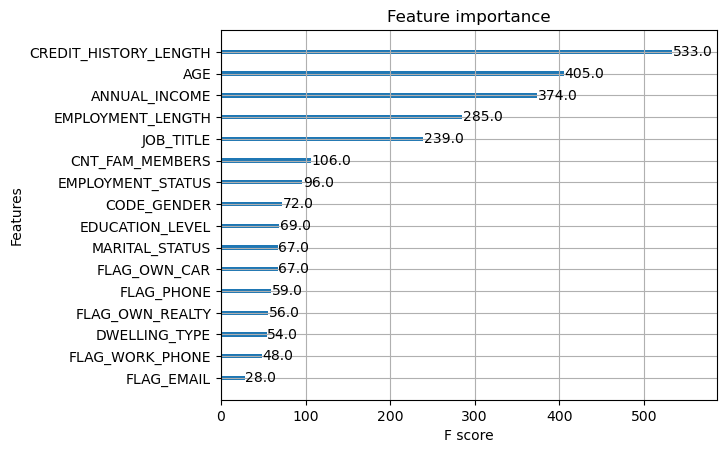

In [ ]:
# Train model
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
model.fit(X_train, y_train)


# Plot feature importance
plot_importance(model)
# Atur ukuran figure
# plt.figure(figsize=(10, 20))  # Lebar 10, tinggi 12
plt.yticks(rotation=0)  # Bisa diganti ke 45 atau 90 jika perlu
plt.show()


In [ ]:
selected_features = [
    "AGE",
    "EMPLOYMENT_LENGTH",
    "CREDIT_HISTORY_LENGTH",
    "ANNUAL_INCOME",
    "JOB_TITLE",
    "EMPLOYMENT_STATUS",
    "CNT_FAM_MEMBERS",
    "IS_BAD"
]

selected_feat_df = new_df[selected_features]
selected_feat_df

,AGE,EMPLOYMENT_LENGTH,CREDIT_HISTORY_LENGTH,ANNUAL_INCOME,JOB_TITLE,EMPLOYMENT_STATUS,CNT_FAM_MEMBERS,IS_BAD
0,-12005,-4542,16,427500.0,NaN,Working,2.0,0
1,-12005,-4542,15,427500.0,NaN,Working,2.0,0
2,-21474,-1134,30,112500.0,Security staff,Working,2.0,0
3,-19110,-3051,5,270000.0,Sales staff,Commercial associate,1.0,0
4,-19110,-3051,5,270000.0,Sales staff,Commercial associate,1.0,0
...,...,...,...,...,...,...,...,...
36452,-17348,-2420,12,315000.0,Managers,Working,2.0,1
36453,-12387,-1325,24,157500.0,Medicine staff,Commercial associate,2.0,1
36454,-12387,-1325,33,157500.0,Medicine staff,Pensioner,2.0,1
36455,-17958,-655,10,283500.0,Sales staff,Working,2.0,0


In [ ]:
def selected_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    # df = apply_xgb_imputation(df)
    # df = adjust_skewness(df)
    # df = binarize_features(df)
    # df = apply_one_hot_encoding(df)
    # df = apply_ordinal_encoding(df)
    # df = scale_features(df)
    # df = apply_oversampling(df)
    return df

In [ ]:
selected_feat_df = selected_preprocess_data(selected_feat_df)
selected_feat_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29579 entries, 0 to 36456
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   AGE                    29579 non-null  float64
 1   EMPLOYMENT_LENGTH      29579 non-null  float64
 2   CREDIT_HISTORY_LENGTH  29579 non-null  int64  
 3   ANNUAL_INCOME          29579 non-null  float64
 4   JOB_TITLE              24559 non-null  object 
 5   EMPLOYMENT_STATUS      29579 non-null  object 
 6   CNT_FAM_MEMBERS        29579 non-null  float64
 7   IS_BAD                 29579 non-null  int32  
dtypes: float64(4), int32(1), int64(1), object(2)
memory usage: 1.9+ MB


In [ ]:
# Inisialisasi scaler
scaler = StandardScaler()
numerical_cols = ["AGE", "EMPLOYMENT_LENGTH", "CREDIT_HISTORY_LENGTH", "ANNUAL_INCOME", "CNT_FAM_MEMBERS"]

# Transformasi numerik dengan cbrt dan standard scaling
for col in numerical_cols:
    selected_feat_df[col] = np.cbrt(selected_feat_df[col])  
    selected_feat_df[col] = scaler.fit_transform(selected_feat_df[[col]])  # Gunakan double bracket

# One-Hot Encoding untuk kolom kategorikal
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_cols = ["JOB_TITLE", "EMPLOYMENT_STATUS"]

for col in categorical_cols:
    encoded = ohe.fit_transform(selected_feat_df[[col]])  # Pastikan input dalam bentuk 2D
    encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out([col]))  
    selected_feat_df = selected_feat_df.drop(columns=[col]).reset_index(drop=True)
    selected_feat_df = pd.concat([selected_feat_df, encoded_df], axis=1)

selected_feat_df

,AGE,EMPLOYMENT_LENGTH,CREDIT_HISTORY_LENGTH,ANNUAL_INCOME,CNT_FAM_MEMBERS,IS_BAD,JOB_TITLE_Accountants,JOB_TITLE_Cleaning staff,JOB_TITLE_Cooking staff,JOB_TITLE_Core staff,JOB_TITLE_Drivers,JOB_TITLE_HR staff,JOB_TITLE_High skill tech staff,JOB_TITLE_IT staff,JOB_TITLE_Laborers,JOB_TITLE_Low-skill Laborers,JOB_TITLE_Managers,JOB_TITLE_Medicine staff,JOB_TITLE_Private service staff,JOB_TITLE_Realty agents,JOB_TITLE_Sales staff,JOB_TITLE_Secretaries,JOB_TITLE_Security staff,JOB_TITLE_Waiters/barmen staff,JOB_TITLE_nan,EMPLOYMENT_STATUS_Commercial associate,EMPLOYMENT_STATUS_Pensioner,EMPLOYMENT_STATUS_State servant,EMPLOYMENT_STATUS_Student,EMPLOYMENT_STATUS_Working
0,-0.799001,0.947014,-0.127712,2.362154,-0.193652,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-0.799001,0.947014,-0.205634,2.362154,-0.193652,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.748574,-0.273543,0.725735,-0.944988,-0.193652,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.242168,0.530025,-1.304405,1.054470,-1.663884,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.242168,0.530025,-1.304405,1.054470,-1.663884,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29574,0.789491,0.266545,-0.462491,1.471004,-0.193652,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
29575,-0.679204,-0.273543,0.402115,-0.244671,-0.193652,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
29576,-0.679204,-0.273543,0.871468,-0.244671,-0.193652,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
29577,0.974242,-0.910705,-0.658630,1.183999,-0.193652,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Split data
X, y = selected_feat_df.drop(columns=['IS_BAD']), selected_feat_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# Apply oversampling only to the training set
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_oversampled, y_train_oversampled = adasyn.fit_resample(X_train, y_train)

# Train and evaluate models on train set
trained_models = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test)

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:56:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23504, number of negative: 23478
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003774 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5992
[LightGBM] [Info] Number of data points in the train set: 46982, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500277 -> initscore=0.001107
[LightGBM] [Info] Start training from score 0.001107
Classifier           Accuracy    Precision    Recall    F1 Score    F2 Score    TP    TN    FP    FN    Business Value Score
-----------------  ----------  -----------  --------  ----------  ----------  ----  ----  ----  ----  ----------------------
Random Forest        0.990534    0.333333   0.217391   0.263158     0.233645    10  5850    20    36              

Dalam percobaan feature selection menggunakan XGBClassifier feature importance pada awalnya kami membuat semua fitur yang kategorikal dengan label encoder lalu kita masukan ke XGBClassifeir dan kita lihat fitur-fitur apa saja yang memiliki F-score tertinggi. Setelah itu kami pilih Beberapa fitur dengan F-score diatas 100 yang akan kami coba sebagai bahan eksperimen dengan harapan terjadi peningkatanhasil prediksi, Namun ternyata feature selection ini tidak ada peningkatan signifikan dari hasil ecalusai nya. Kami memilih untuk menyeleksi fitur berdasarkan hasil eda kami daripada dengan F-score, yang lebih memberikan peningkaytan hasil. 

# Hyperparameter Tuning

In [ ]:
# Hyperparameter tuning dictionary
param_distributions = {
    "Random Forest": {
        "n_estimators": randint(50, 200),
        "max_depth": randint(10, 50),
        "max_features": ["sqrt", "log2"],
        "min_samples_split": randint(2, 10)
    },
    "Extra Trees": {
        "n_estimators": randint(50, 200),
        "max_depth": randint(10, 50),
        "max_features": ["sqrt", "log2"],
        "min_samples_split": randint(2, 10)
    },
    "XGBoost": {
        "n_estimators": randint(50, 200),
        "learning_rate": uniform(0.01, 0.3),
        "max_depth": randint(3, 10),
        "subsample": uniform(0.5, 0.5),
        "colsample_bytree": uniform(0.5, 0.5)
    },
    "LightGBM": {
        "n_estimators": randint(50, 200),
        "learning_rate": uniform(0.01, 0.3),
        "num_leaves": randint(20, 150),
        "max_depth": randint(3, 10),
        "subsample": uniform(0.5, 0.5)
    },
    "CatBoost": {
        "iterations": randint(50, 200),
        "learning_rate": uniform(0.01, 0.3),
        "depth": randint(3, 10)
    }
}

# Hyperparameter tuning function
def tune_hyperparameters(X_train, y_train):
    best_models = {}
    for name, param_grid in param_distributions.items():
        print(f"Tuning hyperparameters for {name}...")
        
        model = {
            "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
            "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
            "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1),
            "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1),
            "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
        }[name]
        
        random_search = RandomizedSearchCV(
            model, param_distributions=param_grid, 
            n_iter=10, cv=3, scoring="f1", n_jobs=-1, verbose=1, random_state=42
        )
        random_search.fit(X_train, y_train)
        best_models[name] = random_search.best_estimator_

        print(f"Best parameters for {name}: {random_search.best_params_}\n")

    return best_models

# Model training and evaluation
def train_result(X_train, X_test, y_train, y_test, models, TP_value=TP_value, TN_value=TN_value, FP_value=FP_value, FN_value=FN_value):
    results = []
    trained_models = {}
    
    for name, clf in models.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        accuration = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1_score = fbeta_score(y_test, y_pred, beta=1)
        f2_score = fbeta_score(y_test, y_pred, beta=2)
        business_value_score = (tp * TP_value) + (tn * TN_value) + (fp * FP_value) + (fn * FN_value)
        
        results.append([name, accuration, precision, recall, f1_score, f2_score, tp, tn, fp, fn, business_value_score])
        trained_models[name] = clf
    
    headers = ["Classifier", "Accuracy", "Precision", "Recall", "F1 Score", "F2 Score", "TP", "TN", "FP", "FN", "Business Value Score"]
    print(tabulate(results, headers=headers))
    
    return trained_models


In [ ]:
def hyp_preprocess_data(df):
    df = remove_outliers(df)
    df = drop_unwanted_features(df)
    df = convert_time_features(df)
    df = handle_retirees(df)
    # df = apply_xgb_imputation(df)
    df = adjust_skewness(df)
    df = binarize_features(df)
    df = apply_one_hot_encoding(df)
    df = apply_ordinal_encoding(df)
    df = scale_features(df)
    # df = apply_oversampling(df)
    return df

In [ ]:
hyp_df = new_df.copy()
hyp_df = hyp_preprocess_data(hyp_df)

# Split data
X, y = hyp_df.drop(columns=['IS_BAD']), hyp_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply oversampling only to the training set
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_oversampled, y_train_oversampled = adasyn.fit_resample(X_train, y_train)

# Hyperparameter tuning harus dilakukan pada dataset yang sudah di-oversample
best_models = tune_hyperparameters(X_train_oversampled, y_train_oversampled)

# Train dan evaluasi juga menggunakan dataset yang sudah di-oversample
trained_models = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test, best_models)

Tuning hyperparameters for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters for Random Forest: {'max_depth': 17, 'max_features': 'sqrt', 'min_samples_split': 6, 'n_estimators': 152}

Tuning hyperparameters for Extra Trees...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters for Extra Trees: {'max_depth': 31, 'max_features': 'sqrt', 'min_samples_split': 3, 'n_estimators': 137}

Tuning hyperparameters for XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:58:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best parameters for XGBoost: {'colsample_bytree': 0.6872700594236812, 'learning_rate': 0.2952142919229748, 'max_depth': 5, 'n_estimators': 121, 'subsample': 0.7993292420985183}

Tuning hyperparameters for LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23462, number of negative: 23478
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11659
[LightGBM] [Info] Number of data points in the train set: 46940, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499830 -> initscore=-0.000682
[LightGBM] [Info] Start training from score -0.000682
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:59:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23462, number of negative: 23478
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004339 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11659
[LightGBM] [Info] Number of data points in the train set: 46940, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499830 -> initscore=-0.000682
[LightGBM] [Info] Start training from score -0.000682
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Classifier       Accuracy    Precision    Recall    F1 Score 

In [ ]:
hyp_df = new_df.copy()
hyp_df = hyp_preprocess_data(hyp_df)

# Split data
X, y = hyp_df.drop(columns=['IS_BAD']), hyp_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

best_models = tune_hyperparameters(X_train, y_train)
trained_models = train_result(X_train, X_test, y_train, y_test, best_models)

Tuning hyperparameters for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters for Random Forest: {'max_depth': 42, 'max_features': 'log2', 'min_samples_split': 3, 'n_estimators': 71}

Tuning hyperparameters for Extra Trees...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters for Extra Trees: {'max_depth': 31, 'max_features': 'sqrt', 'min_samples_split': 3, 'n_estimators': 137}

Tuning hyperparameters for XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [08:00:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best parameters for XGBoost: {'colsample_bytree': 0.6872700594236812, 'learning_rate': 0.2952142919229748, 'max_depth': 5, 'n_estimators': 121, 'subsample': 0.7993292420985183}

Tuning hyperparameters for LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 185, number of negative: 23478
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 390
[LightGBM] [Info] Number of data points in the train set: 23663, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007818 -> initscore=-4.843463
[LightGBM] [Info] Start training from score -4.843463
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [08:00:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 185, number of negative: 23478
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 390
[LightGBM] [Info] Number of data points in the train set: 23663, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007818 -> initscore=-4.843463
[LightGBM] [Info] Start training from score -4.843463
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
def objective(trial, X_train, y_train, model_name):
    """Fungsi untuk Optuna dalam mencari hyperparameter terbaik per model."""
    
    model_params = {
        "Random Forest": {
            "n_estimators": trial.suggest_int("n_estimators", 50, 200),
            "max_depth": trial.suggest_int("max_depth", 5, 50),
            "max_features": trial.suggest_categorical("max_features", ["auto", "sqrt", "log2"])
        },
        "Extra Trees": {
            "n_estimators": trial.suggest_int("n_estimators", 50, 200),
            "max_depth": trial.suggest_int("max_depth", 5, 50),
            "max_features": trial.suggest_categorical("max_features", ["auto", "sqrt", "log2"])
        },
        "XGBoost": {
            "n_estimators": trial.suggest_int("n_estimators", 50, 200),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 10)
        },
        "LightGBM": {
            "n_estimators": trial.suggest_int("n_estimators", 50, 200),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "num_leaves": trial.suggest_int("num_leaves", 20, 150)
        },
        "CatBoost": {
            "iterations": trial.suggest_int("iterations", 50, 200),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "depth": trial.suggest_int("depth", 3, 10)
        }
    }

    model = {
        "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1, **model_params["Random Forest"]),
        "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1, **model_params["Extra Trees"]),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1, **model_params["XGBoost"]),
        "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, **model_params["LightGBM"]),
        "CatBoost": CatBoostClassifier(verbose=0, random_state=42, **model_params["CatBoost"])
    }[model_name]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    return accuracy_score(y_train, y_pred)

def tune_hyperparameters(X_train, y_train):
    best_models = {}

    model_names = ["Random Forest", "Extra Trees", "XGBoost", "LightGBM", "CatBoost"]

    for name in model_names:
        print(f"Tuning {name}...")
        study = optuna.create_study(direction="maximize")
        study.optimize(lambda trial: objective(trial, X_train, y_train, name), n_trials=20)

        best_params = study.best_params
        print(f"Best parameters for {name}: {best_params}\n")

        if name == "Random Forest":
            best_models[name] = RandomForestClassifier(
                random_state=42, n_jobs=-1,
                n_estimators=best_params["n_estimators"],
                max_depth=best_params["max_depth"],
                max_features=best_params["max_features"]
            )
        elif name == "Extra Trees":
            best_models[name] = ExtraTreesClassifier(
                random_state=42, n_jobs=-1,
                n_estimators=best_params["n_estimators"],
                max_depth=best_params["max_depth"],
                max_features=best_params["max_features"]
            )
        elif name == "XGBoost":
            best_models[name] = XGBClassifier(
                use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1,
                n_estimators=best_params["n_estimators"],
                learning_rate=best_params["learning_rate"],
                max_depth=best_params["max_depth"]
            )
        elif name == "LightGBM":
            best_models[name] = LGBMClassifier(
                random_state=42, n_jobs=-1,
                n_estimators=best_params["n_estimators"],
                learning_rate=best_params["learning_rate"],
                num_leaves=best_params["num_leaves"]
            )
        elif name == "CatBoost":
            best_models[name] = CatBoostClassifier(
                verbose=0, random_state=42,
                iterations=best_params["iterations"],
                learning_rate=best_params["learning_rate"],
                depth=best_params["depth"]
            )

    return best_models


def fbeta_score(y_true, y_pred, beta=2):
    """Menghitung F2 Score secara manual."""
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    if precision + recall == 0:
        return 0
    return (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)

def calculate_business_value(tp, tn, fp, fn):
    """Contoh perhitungan Business Value Score (bisa disesuaikan dengan kebutuhan bisnis)."""
    return tp * TP_value + tn * TN_value + fp * FP_value + fn * FN_value

def train_result(X_train, X_test, y_train, y_test, best_models):
    results = []

    for name, model in best_models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Menghitung metrik evaluasi
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        f2 = fbeta_score(y_test, y_pred, beta=2)

        # Menghitung confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        # Menghitung business value score
        business_value = calculate_business_value(tp, tn, fp, fn)

        results.append([name, accuracy, precision, recall, f1, f2, tp, tn, fp, fn, business_value])

    # Membuat DataFrame untuk tampilan tabel
    df_results = pd.DataFrame(results, columns=[
        "Classifier","Accuracy", "Precision", "Recall", "F1 Score", "F2 Score", 
        "TP", "TN", "FP", "FN", "Business Value Score"
    ])

    # Menampilkan tabel dengan format rapi
    print(df_results.to_string(index=False))
    
    return df_results



In [ ]:
hyp_df = new_df.copy()
hyp_df = hyp_preprocess_data(hyp_df)

# Split data
X, y = hyp_df.drop(columns=['IS_BAD']), hyp_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply oversampling only to the training set
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_oversampled, y_train_oversampled = adasyn.fit_resample(X_train, y_train)

# Hyperparameter tuning harus dilakukan pada dataset yang sudah di-oversample
best_models = tune_hyperparameters(X_train_oversampled, y_train_oversampled)

# Train dan evaluasi juga menggunakan dataset yang sudah di-oversample
trained_models = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test, best_models)

[I 2025-03-11 08:00:57,755] A new study created in memory with name: no-name-4f41f6e6-12d3-449d-8ce2-69c0081eb584


Tuning Random Forest...


c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 5, 'high': 50}
  warnings.warn(
[I 2025-03-11 08:00:59,546] Trial 0 finished with value: 0.9955262036642523 and parameters: {'n_estimators': 121, 'max_depth': 13, 'max_features': 'sqrt', 'learning_rate': 0.28442823727055283, 'num_leaves': 82, 'iterations': 89, 'depth': 8}. Best is trial 0 with value: 0.9955262036642523.
c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the

Best parameters for Random Forest: {'n_estimators': 180, 'max_depth': 49, 'max_features': 'auto', 'learning_rate': 0.09212278805785276, 'num_leaves': 109, 'iterations': 135, 'depth': 4}

Tuning Extra Trees...


[I 2025-03-11 08:02:00,257] Trial 0 finished with value: 0.9997869620792501 and parameters: {'n_estimators': 153, 'max_depth': 50, 'max_features': 'sqrt', 'learning_rate': 0.09875471356751249, 'num_leaves': 88, 'iterations': 184, 'depth': 3}. Best is trial 0 with value: 0.9997869620792501.
c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 5, 'high': 50}
  warnings.warn(
[I 2025-03-11 08:02:01,434] Trial 1 finished with value: 0.9847890924584576 and parameters: {'n_estimators': 119, 'max_depth': 14, 'max_features': 'log2', 'learning_rate': 0.22157810634676894, 'num_leaves': 44, 'iteration

...

Best parameters for LightGBM: {'n_estimators': 80, 'max_depth': 5, 'max_features': 'auto', 'learning_rate': 0.25214595455195127, 'num_leaves': 99, 'iterations': 136, 'depth': 6}

Tuning CatBoost...


[I 2025-03-11 08:04:55,050] Trial 0 finished with value: 0.9936088623775032 and parameters: {'n_estimators': 62, 'max_depth': 50, 'max_features': 'auto', 'learning_rate': 0.03643069302299906, 'num_leaves': 96, 'iterations': 53, 'depth': 10}. Best is trial 0 with value: 0.9936088623775032.
c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 5, 'high': 50}
  warnings.warn(
[I 2025-03-11 08:04:56,631] Trial 1 finished with value: 0.9929271410311036 and parameters: {'n_estimators': 81, 'max_depth': 23, 'max_features': 'log2', 'learning_rate': 0.1376983974488098, 'num_leaves': 146, 'iterations'

Best parameters for CatBoost: {'n_estimators': 70, 'max_depth': 43, 'max_features': 'auto', 'learning_rate': 0.2590761982230755, 'num_leaves': 44, 'iterations': 180, 'depth': 10}

Training Random Forest...
Training Extra Trees...
Training XGBoost...


c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [08:08:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23462, number of negative: 23478
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004346 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11659
[LightGBM] [Info] Number of data points in the train set: 46940, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499830 -> initscore=-0.000682
[LightGBM] [Info] Start training from score -0.000682
Training CatBoost...
   Classifier  Accuracy  Precision   Recall  F1 Score  F2 Score  TP   TN  FP  FN  Business Value Score
Random Forest  0.991886   0.458333 0.239130  0.314286  0.264423  11 5857  13  35                569100
  Extra Trees  0.991210   0.400000 0.260870  0.315789  0.280374  12 5852  18  34                568800
      XGBo

In [ ]:
# Train dan evaluasi juga menggunakan dataset yang sudah di-oversample
trained_models = train_result(X_train_oversampled, X_test, y_train_oversampled, y_test, best_models)

Training Random Forest...


c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Training Extra Trees...
Training XGBoost...


c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [08:09:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23462, number of negative: 23478
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006408 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11659
[LightGBM] [Info] Number of data points in the train set: 46940, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499830 -> initscore=-0.000682
[LightGBM] [Info] Start training from score -0.000682
Training CatBoost...
   Classifier  Accuracy  Precision   Recall  F1 Score  F2 Score  TP   TN  FP  FN  Business Value Score
Random Forest  0.991886   0.458333 0.239130  0.314286  0.264423  11 5857  13  35                569100
  Extra Trees  0.991210   0.400000 0.260870  0.315789  0.280374  12 5852  18  34                568800
      XGBo

In [ ]:
hyp_df = new_df.copy()
hyp_df = hyp_preprocess_data(hyp_df)

# Split data
X, y = hyp_df.drop(columns=['IS_BAD']), hyp_df['IS_BAD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

best_models = tune_hyperparameters(X_train, y_train)
trained_models = train_result(X_train, X_test, y_train, y_test, best_models)

[I 2025-03-11 08:09:46,947] A new study created in memory with name: no-name-0a6a62f0-fd71-4cfe-bf0b-190d3c0be86e


Tuning Random Forest...


c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 5, 'high': 50}
  warnings.warn(
[I 2025-03-11 08:09:47,589] Trial 0 finished with value: 0.998774458014622 and parameters: {'n_estimators': 94, 'max_depth': 21, 'max_features': 'log2', 'learning_rate': 0.17143761513330583, 'num_leaves': 110, 'iterations': 151, 'depth': 6}. Best is trial 0 with value: 0.998774458014622.
c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the 

Best parameters for Random Forest: {'n_estimators': 121, 'max_depth': 42, 'max_features': 'log2', 'learning_rate': 0.2229117647354147, 'num_leaves': 47, 'iterations': 52, 'depth': 6}

Tuning Extra Trees...


[I 2025-03-11 08:10:03,963] Trial 0 finished with value: 0.9995773993153869 and parameters: {'n_estimators': 161, 'max_depth': 36, 'max_features': 'sqrt', 'learning_rate': 0.07657540744953008, 'num_leaves': 90, 'iterations': 78, 'depth': 3}. Best is trial 0 with value: 0.9995773993153869.
c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 5, 'high': 50}
  warnings.warn(
[I 2025-03-11 08:10:04,820] Trial 1 finished with value: 0.9993238389046191 and parameters: {'n_estimators': 141, 'max_depth': 27, 'max_features': 'log2', 'learning_rate': 0.0629234781724986, 'num_leaves': 79, 'iterations'

...

Best parameters for LightGBM: {'n_estimators': 146, 'max_depth': 44, 'max_features': 'auto', 'learning_rate': 0.07081190274834648, 'num_leaves': 139, 'iterations': 77, 'depth': 4}

Tuning CatBoost...


[I 2025-03-11 08:10:47,912] Trial 0 finished with value: 0.9926467480877319 and parameters: {'n_estimators': 51, 'max_depth': 17, 'max_features': 'sqrt', 'learning_rate': 0.11704165765971397, 'num_leaves': 52, 'iterations': 114, 'depth': 5}. Best is trial 0 with value: 0.9926467480877319.
c:\Users\LENOVO\anaconda3\Lib\site-packages\optuna\trial\_trial.py:678: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 5, 'high': 50}
  warnings.warn(
[I 2025-03-11 08:10:49,151] Trial 1 finished with value: 0.9926890081561932 and parameters: {'n_estimators': 106, 'max_depth': 14, 'max_features': 'sqrt', 'learning_rate': 0.15836870168005587, 'num_leaves': 80, 'iterations

Best parameters for CatBoost: {'n_estimators': 88, 'max_depth': 26, 'max_features': 'log2', 'learning_rate': 0.2983275659776865, 'num_leaves': 137, 'iterations': 197, 'depth': 10}

Training Random Forest...
Training Extra Trees...
Training XGBoost...


c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [08:12:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 185, number of negative: 23478
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001905 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 390
[LightGBM] [Info] Number of data points in the train set: 23663, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007818 -> initscore=-4.843463
[LightGBM] [Info] Start training from score -4.843463
Training CatBoost...
   Classifier  Accuracy  Precision   Recall  F1 Score  F2 Score  TP   TN  FP  FN  Business Value Score
Random Forest  0.992055   0.470588 0.173913  0.253968  0.199005   8 5861   9  38                567800
  Extra Trees  0.991886   0.458333 0.239130  0.314286  0.264423  11 5857  13  35                569100
      XGBoost 

In [ ]:
best_models

{'Random Forest': RandomForestClassifier(max_depth=42, max_features='log2', n_estimators=121,
                        n_jobs=-1, random_state=42),
 'Extra Trees': ExtraTreesClassifier(max_depth=36, n_estimators=161, n_jobs=-1, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.2055696900695071, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=35, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=119, n_jobs=-1,
         

In [ ]:
trained_models_adasyn

{'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Extra Trees': ExtraTreesClassifier(n_jobs=-1, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=-1, num_parallel_tree=None, random_state=42, ...),
 'LightGBM': LGBMClassifier(n_jobs=-1, random_state=42),
 'CatBoost': <catboost.co

Setelah melakukan percobaan hyperparameter tuning dengan RandomSearch dan Optuna, didapatkan Optuna menghasilkan hasil evaluasi yang paling baik dan ada peningkatan sedikit di bagian evaluasi. Untuk pemilihan dan eksperimen hyperparameter tuning yang lebih rinci tersedia di notebook eksperimen modeling kedua.

# Save Model

In [ ]:
# import pickle

# # Simpan model XGBoost
# with open('xgboost_model.pkl', 'wb') as file:
#     pickle.dump(best_models['XGBoost'], file)

# # Simpan model LightGBM
# with open('lightgbm_model.pkl', 'wb') as file:
#     pickle.dump(best_models['LightGBM'], file)



In [ ]:
# # Simpan model Random Forest
# with open('random_forest.pkl', 'wb') as file:
#     pickle.dump(trained_models_adasyn['Random Forest'], file)